In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [5]:
fn_datalo = f'../data/quaia_G20.0.fits'
fn_datahi = f'../data/quaia_G20.5.fits'

fn_randlo = f'../data/randoms/random_G20.0_10x.fits'
fn_randhi = f'../data/randoms/random_G20.5_10x.fits'

fn_randlo_zbin0 = f'../data/randoms/random_G20.0_zsplit2bin0_10x.fits'
fn_randlo_zbin1 = f'../data/randoms/random_G20.0_zsplit2bin1_10x.fits'

fn_randhi_zbin0 = f'../data/randoms/random_G20.5_zsplit2bin0_10x.fits'
fn_randhi_zbin1 = f'../data/randoms/random_G20.5_zsplit2bin1_10x.fits'

In [4]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

In [123]:
fn_sello_zbin0 = f'../data/maps/selection_function_NSIDE64_G20.0_zsplit2bin0.fits'
fn_sello_zbin1 = f'../data/maps/selection_function_NSIDE64_G20.0_zsplit2bin1.fits'

fn_selhi_zbin0 = f'../data/maps/selection_function_NSIDE64_G20.5_zsplit2bin0.fits'
fn_selhi_zbin1 = f'../data/maps/selection_function_NSIDE64_G20.5_zsplit2bin1.fits'

## Parameters

In [8]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [9]:
G_hi = 20.5
G_lo = 20.0

In [10]:
nthreads = 18

In [11]:
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

In [12]:
selfunc_hi_zbin0 = hp.fitsfunc.read_map(fn_selhi_zbin0)
selfunc_hi_zbin1 = hp.fitsfunc.read_map(fn_selhi_zbin1)

In [13]:
mask_type = 'selfunc'

## Quasar data catalog

In [14]:
tab_datahi = Table.read(fn_datahi)
N_datahi = len(tab_datahi)
print(f"Number of data sources: {N_datahi}")

Number of data sources: 1295502


In [15]:
pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
mask_datahi = selfunc_hi[pixel_indices_datahi]>=0.5
N_datahi_mask = len(tab_datahi['ra'][mask_datahi])

In [16]:
cut = np.median(tab_datahi['redshift_quaia'])

In [17]:
mask_datahi_zbin0 = selfunc_hi_zbin0[pixel_indices_datahi]>=0.5 
mask_datahi_zbin1 = selfunc_hi_zbin1[pixel_indices_datahi]>=0.5

In [18]:
tab_datahi_zbin0 = tab_datahi[mask_datahi_zbin0][tab_datahi['redshift_quaia'][mask_datahi_zbin0]<cut]
N_datahi_mask_zbin0 = len(tab_datahi_zbin0)

tab_datahi_zbin1 = tab_datahi[mask_datahi_zbin1][tab_datahi['redshift_quaia'][mask_datahi_zbin1]>=cut]
N_datahi_mask_zbin1 = len(tab_datahi_zbin1)

In [19]:
# pixel_indices_datahi_zbin0 = hp.ang2pix(NSIDE, tab_datahi['ra'][tab_datahi['redshift_quaia']<cut], 
#                                         tab_datahi['dec'][tab_datahi['redshift_quaia']<cut], lonlat=True)
# mask_datahi_zbin0 = selfunc_hi_zbin0[pixel_indices_datahi_zbin0]>=0.5
# tab_datahi_zbin0 = tab_datahi[tab_datahi['redshift_quaia']<cut][mask_datahi_zbin0]
# N_datahi_mask_zbin0 = len(tab_datahi_zbin0)

In [20]:
# pixel_indices_datahi_zbin1 = hp.ang2pix(NSIDE, tab_datahi['ra'][tab_datahi['redshift_quaia']>=cut], 
#                                         tab_datahi['dec'][tab_datahi['redshift_quaia']>=cut], lonlat=True)
# mask_datahi_zbin1 = selfunc_hi_zbin1[pixel_indices_datahi_zbin1]>=0.5
# tab_datahi_zbin1 = tab_datahi[tab_datahi['redshift_quaia']>=cut][mask_datahi_zbin1]
# N_datahi_mask_zbin1 = len(tab_datahi_zbin1)

## Random catalog

In [21]:
tab_randhi = Table.read(fn_randhi)
N_randhi = len(tab_randhi)
print(f"Number of random sources: {N_randhi}")

Number of random sources: 12955802


In [22]:
pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
mask_randhi = selfunc_hi[pixel_indices_randhi]>=0.5
N_randhi_mask = len(tab_randhi['ra'][mask_randhi])

In [23]:
mask_randhi_zbin0 = selfunc_hi_zbin0[pixel_indices_randhi]>=0.5
mask_randhi_zbin1 = selfunc_hi_zbin1[pixel_indices_randhi]>=0.5

In [24]:
# key = quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, plot = True, mask_type = mask_type)

/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:208: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  z = np.sort(tab_gcatlo['redshift_quaia'][mask_gcatlo])
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:220: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  plt.hist(tab_gcatlo['redshift_quaia'][mask_gcatlo], cumulative = True, density = True, bins = 100)


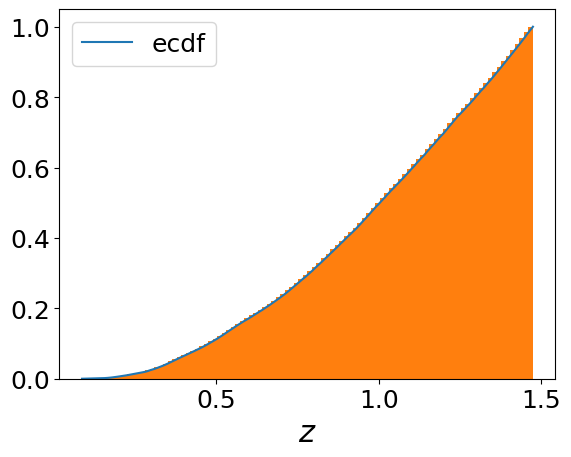

In [25]:
key_zbin0 = quaia.z_dist(tab_datahi[mask_datahi_zbin0], tab_randhi, [tab_datahi['redshift_quaia'][mask_datahi_zbin0]<cut], 
                         np.full(N_randhi, True), N_datahi_mask_zbin0, N_randhi, plot = True, mask_type = mask_type+'_zbin0')

/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:208: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  z = np.sort(tab_gcatlo['redshift_quaia'][mask_gcatlo])
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:220: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  plt.hist(tab_gcatlo['redshift_quaia'][mask_gcatlo], cumulative = True, density = True, bins = 100)


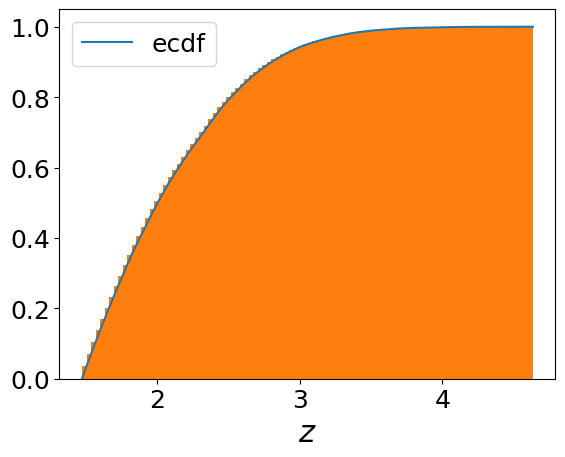

In [26]:
key_zbin1 = quaia.z_dist(tab_datahi[mask_datahi_zbin1], tab_randhi, [tab_datahi['redshift_quaia'][mask_datahi_zbin1]>=cut], 
                         np.full(N_randhi, True), N_datahi_mask_zbin1, N_randhi, plot = True, mask_type = mask_type+'_zbin1')

In [27]:
# pixel_indices_randhi_zbin0 = hp.ang2pix(NSIDE, tab_randhi['ra'][tab_randhi['redshift_quaia_'+mask_type+'_zbin0']<cut], 
#                                         tab_datahi['dec'][tab_randhi['redshift_quaia_'+mask_type+'_zbin0']<cut], lonlat=True)
# mask_randhi_zbin0 = selfunc_hi_zbin0[pixel_indices_randhi_zbin0]>=0.5
# tab_randhi_zbin0 = tab_randhi[tab_datahi['redshift_quaia_'+mask_type+'_zbin0']<cut][mask_randhi_zbin0]
# N_randhi_mask_zbin0 = len(tab_randhi_zbin0)

In [28]:
tab_randhi_zbin0 = tab_randhi[mask_randhi_zbin0][tab_randhi['redshift_quaia_'+mask_type+'_zbin0'][mask_randhi_zbin0]<cut]
N_randhi_mask_zbin0 = len(tab_randhi_zbin0)

tab_randhi_zbin1 = tab_randhi[mask_randhi_zbin1][tab_randhi['redshift_quaia_'+mask_type+'_zbin1'][mask_randhi_zbin1]>=cut]
N_randhi_mask_zbin1 = len(tab_randhi_zbin1)

# Compute clustering in two z bins
## Define a function

In [153]:
def zbins(fn_datahi, fn_randhi, fn_selhi_zbin0, fn_selhi_zbin1, fn_selhi, plot = False):
    
    # parameters
    selfunc_hi_zbin0 = hp.fitsfunc.read_map(fn_selhi_zbin0)
    selfunc_hi_zbin1 = hp.fitsfunc.read_map(fn_selhi_zbin1)

    # quasar data catalog
    tab_datahi = Table.read(fn_datahi)
    N_datahi = len(tab_datahi)
    print(f"Number of data sources: {N_datahi}")

    pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
    mask_datahi_zbin0 = selfunc_hi_zbin0[pixel_indices_datahi]>=0.5 
    mask_datahi_zbin1 = selfunc_hi_zbin1[pixel_indices_datahi]>=0.5

    # impose zbin and selfunc mask on data
    cut = np.median(tab_datahi['redshift_quaia'])
    tab_datahi_zbin0 = tab_datahi[mask_datahi_zbin0][tab_datahi['redshift_quaia'][mask_datahi_zbin0]<cut]
    tab_datahi_zbin1 = tab_datahi[mask_datahi_zbin1][tab_datahi['redshift_quaia'][mask_datahi_zbin1]>=cut]
    
    # record N in each bin
    N_datahi_mask_zbin0 = len(tab_datahi_zbin0)
    N_datahi_mask_zbin1 = len(tab_datahi_zbin1)
    
    # random catalog
    tab_randhi = Table.read(fn_randhi)
    N_randhi = len(tab_randhi)
    print(f"Number of random sources: {N_randhi}")
    
    # split randoms in two 
    # tab_randhi_zbin0_nomask = tab_randhi[:int(N_randhi/2)]
    # tab_randhi_zbin1_nomask = tab_randhi[int(N_randhi/2):]
    rng = np.random.default_rng(2023)
    ind_zbin0 = rng.choice(list(range(N_randhi)), size = int(N_randhi/2), replace = False)
    ind_zbin1 = np.setdiff1d(list(range(N_randhi)), ind_zbin0)
    
    # get the pixel indices for objects in each random zbin
    pixel_indices_randhi_zbin0 = hp.ang2pix(NSIDE, tab_randhi[ind_zbin0]['ra'], tab_randhi[ind_zbin0]['dec'], lonlat=True)
    pixel_indices_randhi_zbin1 = hp.ang2pix(NSIDE, tab_randhi[ind_zbin1]['ra'], tab_randhi[ind_zbin1]['dec'], lonlat=True)

    # select where the randoms in each zbin pass the selfunc mask
    # mask_randhi_zbin0 = selfunc_hi_zbin0[pixel_indices_randhi]>=0.5
    # mask_randhi_zbin1 = selfunc_hi_zbin1[pixel_indices_randhi]>=0.5
    mask_randhi_zbin0 = selfunc_hi_zbin0[pixel_indices_randhi_zbin0]>=0.5
    mask_randhi_zbin1 = selfunc_hi_zbin1[pixel_indices_randhi_zbin1]>=0.5

    # assign redshifts to randoms in each zbin, mimicking the distribution of data in each zbin that pass the selfunc mask
    # ind_zbin0 = np.random.choice(list(range(N_randhi)), size = int(N_randhi/2), replace = False)
    tab_randhi_zbin0 = tab_randhi[ind_zbin0][mask_randhi_zbin0]
    N_randhi_mask_zbin0 = len(tab_randhi_zbin0)
    key_zbin0 = quaia.z_dist(tab_datahi[mask_datahi_zbin0], tab_randhi_zbin0,
                             [tab_datahi['redshift_quaia'][mask_datahi_zbin0]<cut], np.full(N_randhi_mask_zbin0, True), 
                             N_datahi_mask_zbin0, N_randhi_mask_zbin0, plot = plot, mask_type = mask_type+'_zbin0')

    # ind_zbin1 = np.setdiff1d(list(range(N_randhi)), ind_zbin0)
    tab_randhi_zbin1 = tab_randhi[ind_zbin1][mask_randhi_zbin1]
    N_randhi_mask_zbin1 = len(tab_randhi_zbin1)
    key_zbin1 = quaia.z_dist(tab_datahi[mask_datahi_zbin1], tab_randhi_zbin1, 
                             [tab_datahi['redshift_quaia'][mask_datahi_zbin1]>=cut], np.full(N_randhi_mask_zbin1, True), 
                             N_datahi_mask_zbin1, N_randhi_mask_zbin1, plot = plot, mask_type = mask_type+'_zbin1')

    # select the randoms that pass the selfunc mask
    # tab_randhi_zbin0 = tab_randhi[mask_randhi_zbin0][tab_randhi['redshift_quaia_'+mask_type+'_zbin0'][mask_randhi_zbin0]<cut]
    # N_randhi_mask_zbin0 = len(tab_randhi_zbin0[mask_randhi_zbin0])

    # tab_randhi_zbin1 = tab_randhi[mask_randhi_zbin1][tab_randhi['redshift_quaia_'+mask_type+'_zbin1'][mask_randhi_zbin1]>=cut]
    # N_randhi_mask_zbin1 = len(tab_randhi_zbin1[mask_randhi_zbin1])

    # plot data
    bins = np.linspace(0.08, 4.6, 100)
    selfunc_hi = hp.fitsfunc.read_map(fn_selhi)
    mask_datahi = selfunc_hi[pixel_indices_datahi]>=0.5
    plt.hist(tab_datahi['redshift_quaia'][mask_datahi], histtype = 'step', label = 'Quaia', bins = bins, linewidth = 2.5)
    plt.hist(tab_datahi_zbin0['redshift_quaia'], alpha = 0.5, label = 'low z', bins = bins, linestyle = '--', linewidth = 2.5)
    plt.hist(tab_datahi_zbin1['redshift_quaia'], alpha = 0.5,  label = 'high z', bins = bins, linestyle = '--', linewidth = 2.5)
    plt.xlabel('Redshift')
    plt.ylabel('QSO number counts')
    plt.yscale('log')
    plt.ylim(125,)
    plt.legend()
    plt.show()
        
    # for comparison purposes
    pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
    mask_randhi = selfunc_hi[pixel_indices_randhi]>=0.5
    N_randhi_mask = len(tab_randhi['ra'][mask_randhi])
    N_datahi_mask = len(tab_datahi['ra'][mask_datahi])
    
    # plot randoms
    quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)   
    plt.hist(tab_randhi['redshift_quaia_'+mask_type], histtype = 'step', label = 'Randoms', bins = bins, linewidth = 2.5)
    plt.hist(tab_randhi_zbin0['redshift_quaia_'+mask_type+'_zbin0'], alpha = 0.5, label = 'low z', bins = bins, linestyle = '--', 
             linewidth = 2.5)
    plt.hist(tab_randhi_zbin1['redshift_quaia_'+mask_type+'_zbin1'], alpha = 0.5,  label = 'high z', bins = bins, linestyle = '--', 
             linewidth = 2.5)
    plt.xlabel('Redshift')
    plt.ylabel('QSO number counts')
    plt.yscale('log')
    plt.ylim(125,)
    plt.legend()
    plt.show() # is this okay?
    
    return (tab_datahi_zbin0, tab_datahi_zbin1, tab_randhi_zbin0, tab_randhi_zbin1, N_datahi_mask_zbin0, N_datahi_mask_zbin1, 
            len(tab_randhi_zbin0), len(tab_randhi_zbin1), key_zbin0, key_zbin1)

Number of data sources: 1295502
Number of random sources: 12955802


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:208: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  z = np.sort(tab_gcatlo['redshift_quaia'][mask_gcatlo])
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:208: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  z = np.sort(tab_gcatlo['redshift_quaia'][mask_gcatlo])


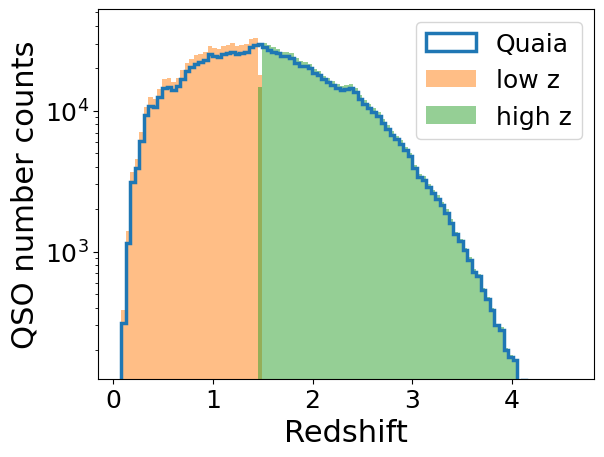

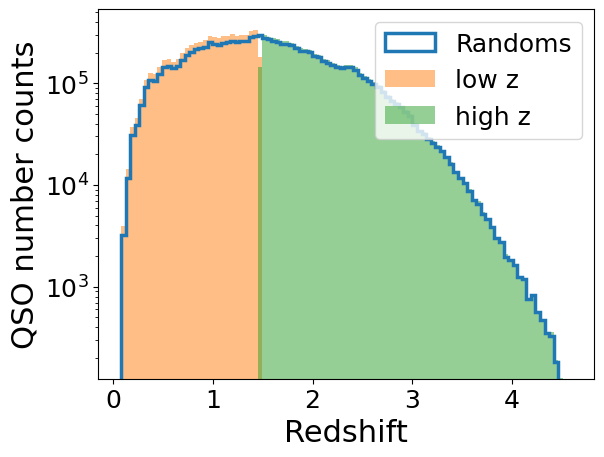

In [154]:
(tab_datahi_zbin0, tab_datahi_zbin1, tab_randhi_zbin0, tab_randhi_zbin1, N_datahi_mask_zbin0, N_datahi_mask_zbin1, 
 N_randhi_mask_zbin0, N_randhi_mask_zbin1, key_zbin0, key_zbin1) = zbins(fn_datahi, fn_randhi, fn_selhi_zbin0, fn_selhi_zbin1, 
                                                                         fn_selhi)

Number of data sources: 755850
Number of random sources: 7563151


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:208: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  z = np.sort(tab_gcatlo['redshift_quaia'][mask_gcatlo])
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:208: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  z = np.sort(tab_gcatlo['redshift_quaia'][mask_gcatlo])


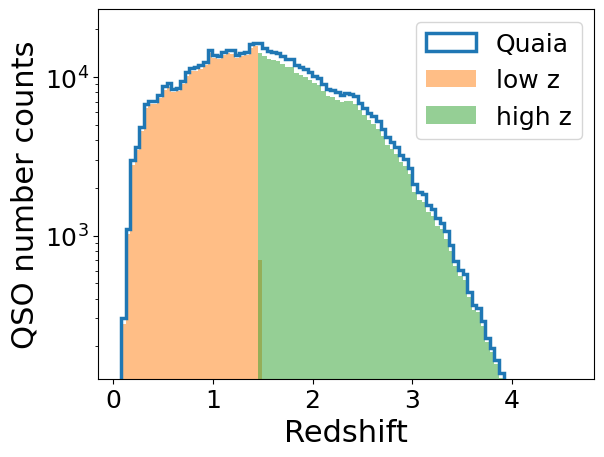

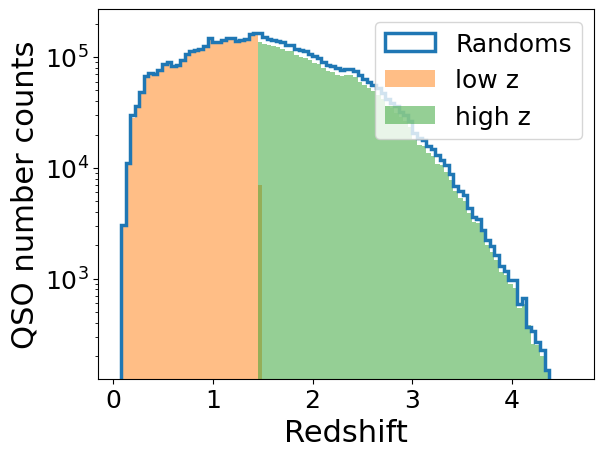

In [155]:
(tab_datalo_zbin0, tab_datalo_zbin1, tab_randlo_zbin0, tab_randlo_zbin1, N_datalo_mask_zbin0, N_datalo_mask_zbin1, 
 N_randlo_mask_zbin0, N_randlo_mask_zbin1, key_zbin0, key_zbin1) = zbins(fn_datalo, fn_randlo, fn_sello_zbin0, fn_sello_zbin1, 
                                                                         fn_sello)

## $\xi(r)$

In [156]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# # Create the bins array
# rmin = 0.1 # 0.1 # start higher
# rmax = 155.0 # 20.0 #50.0
# nbins = 20 #90 #20
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [157]:
cf_datahi_zbin0, ravg_datahi_zbin0 = quaia.xi_r(tab_datahi_zbin0, tab_randhi_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, 
                                                key_zbin0, nthreads = nthreads, rbins = rbins)

In [158]:
cf_datahi_zbin1, ravg_datahi_zbin1 = quaia.xi_r(tab_datahi_zbin1, tab_randhi_zbin1, N_datahi_mask_zbin1, N_randhi_mask_zbin1, 
                                                key_zbin1, nthreads = nthreads, rbins = rbins)

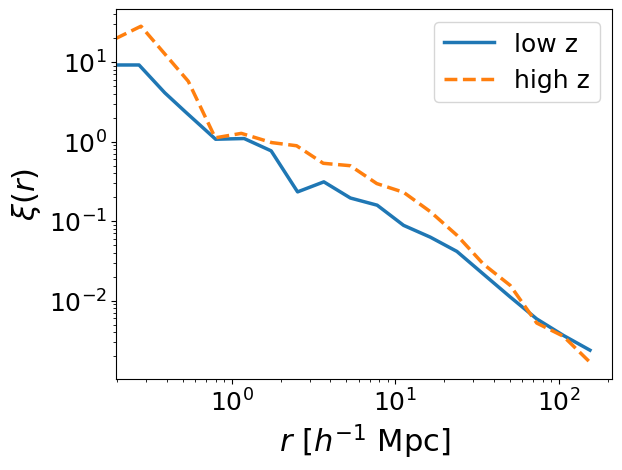

In [159]:
plt.plot(ravg_datahi_zbin0, cf_datahi_zbin0, label = 'low z', linewidth = 2.5)
plt.plot(ravg_datahi_zbin1, cf_datahi_zbin1, label = 'high z', linewidth = 2.5, linestyle = '--')
plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
# plt.ylim(-1,)
plt.legend()
plt.show()

In [160]:
cf_datalo_zbin0, ravg_datalo_zbin0 = quaia.xi_r(tab_datalo_zbin0, tab_randlo_zbin0, N_datalo_mask_zbin0, N_randlo_mask_zbin0, 
                                                key_zbin0, nthreads = nthreads, rbins = rbins)

In [161]:
cf_datalo_zbin1, ravg_datalo_zbin1 = quaia.xi_r(tab_datalo_zbin1, tab_randlo_zbin1, N_datalo_mask_zbin1, N_randlo_mask_zbin1, 
                                                key_zbin1, nthreads = nthreads, rbins = rbins)

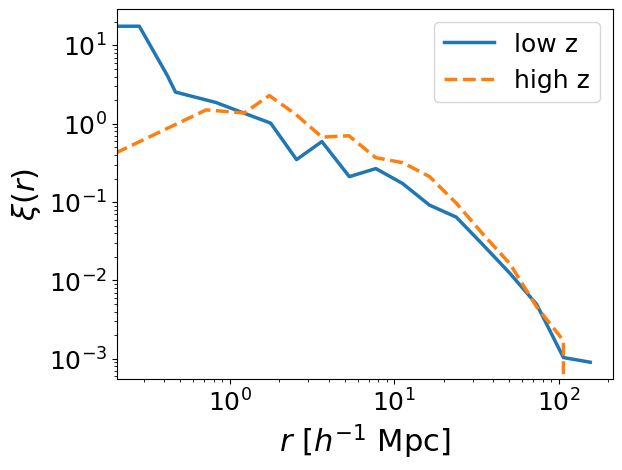

In [162]:
plt.plot(ravg_datalo_zbin0, cf_datalo_zbin0, label = 'low z', linewidth = 2.5)
plt.plot(ravg_datalo_zbin1, cf_datalo_zbin1, label = 'high z', linewidth = 2.5, linestyle = '--')
plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
# plt.ylim(-1,)
plt.legend()
plt.show()

## $w_p(r_p)$

In [46]:
# Create the bins array
rmin = 0.15 # 0.5 # 0.1 # start higher
rmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 210 # 120 #85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [61]:
pimax = 80 # 40 # 5000.0 # 40.0

In [62]:
wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia.wp_rp(tab_datahi_zbin0, tab_randhi_zbin0, N_datahi_mask_zbin0, N_datahi_mask_zbin0, 
                                                  key_zbin0, nthreads = nthreads, rbins = rbins, nbins = nbins, pimax = pimax)

[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


In [63]:
wp_datahi_zbin1, rpavg_datahi_zbin1 = quaia.wp_rp(tab_datahi_zbin1, tab_randhi_zbin1, N_datahi_mask_zbin1, N_datahi_mask_zbin1, 
                                                  key_zbin1, nthreads = nthreads, rbins = rbins, nbins = nbins, pimax = pimax)

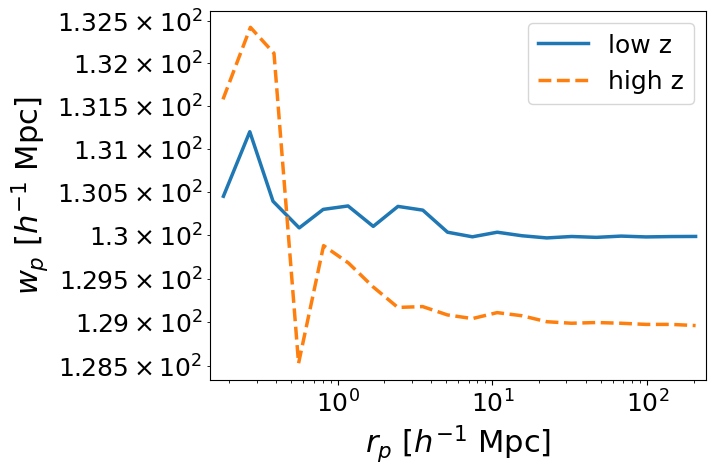

In [64]:
plt.plot(rpavg_datahi_zbin0, wp_datahi_zbin0, label = 'low z', linewidth = 2.5)
plt.plot(rpavg_datahi_zbin1, wp_datahi_zbin1, label = 'high z', linewidth = 2.5, linestyle = '--')
plt.xlabel(r'$r_{p}$ $[h^{-1}$ Mpc]') # projected
plt.ylabel("$w_p$ $[h^{-1}$ Mpc]")
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
plt.xlim(rmin, rmax)
plt.legend()
plt.show()

In [65]:
wp_datalo_zbin0, rpavg_datalo_zbin0 = quaia.wp_rp(tab_datalo_zbin0, tab_randlo_zbin0, N_datalo_mask_zbin0, N_datalo_mask_zbin0, 
                                                  key_zbin0, nthreads = nthreads, rbins = rbins, nbins = nbins, pimax = pimax)

In [66]:
wp_datalo_zbin1, rpavg_datalo_zbin1 = quaia.wp_rp(tab_datalo_zbin1, tab_randlo_zbin1, N_datalo_mask_zbin1, N_datalo_mask_zbin1, 
                                                  key_zbin1, nthreads = nthreads, rbins = rbins, nbins = nbins, pimax = pimax)

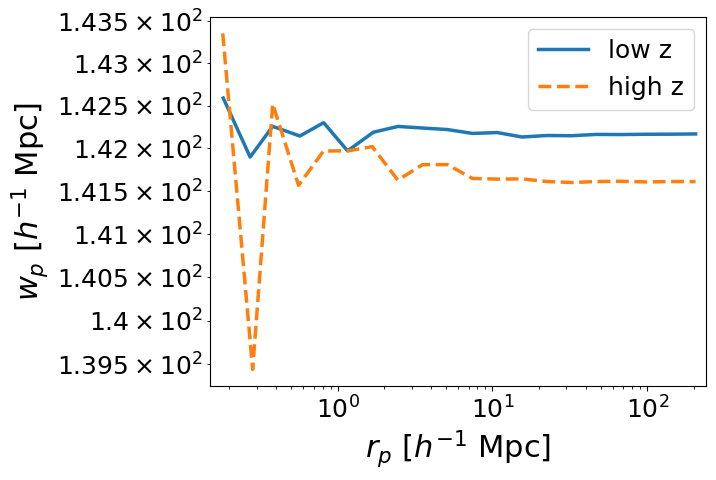

In [67]:
plt.plot(rpavg_datalo_zbin0, wp_datalo_zbin0, label = 'low z', linewidth = 2.5)
plt.plot(rpavg_datalo_zbin1, wp_datalo_zbin1, label = 'high z', linewidth = 2.5, linestyle = '--')
plt.xlabel(r'$r_{p}$ $[h^{-1}$ Mpc]') # projected
plt.ylabel("$w_p$ $[h^{-1}$ Mpc]")
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
plt.xlim(rmin, rmax)
plt.legend()
plt.show()

## $w(\theta)$

In [98]:
# Create the bins array
# thetabins = np.logspace(np.log10(0.1), np.log10(10), 15) 
thetabins = np.logspace(np.log10(0.1), np.log10(35), 15) #(np.log10(0.15), np.log10(35), 15)

In [99]:
wp_data_zbin0 = quaia.w_theta(tab_datahi_zbin0, tab_randhi_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, nthreads = nthreads, 
                              thetabins = thetabins)

In [100]:
wp_data_zbin1 = quaia.w_theta(tab_datahi_zbin1, tab_randhi_zbin1, N_datahi_mask_zbin1, N_randhi_mask_zbin1, nthreads = nthreads, 
                              thetabins = thetabins)

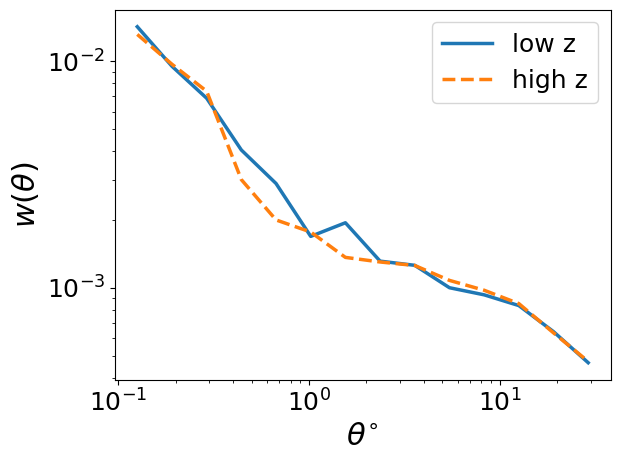

In [101]:
plt.plot(quaia.recenter(thetabins), wp_data_zbin0, label = 'low z', linewidth = 2.5)
plt.plot(quaia.recenter(thetabins), wp_data_zbin1, label = 'high z', linestyle = '--', linewidth = 2.5)
plt.xlabel(r'$\theta^{\circ}$')
plt.ylabel(r"$w(\theta)$")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()